# import

In [1]:
import copy
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from shapely.affinity import affine_transform
from shapely.geometry import Point, LineString, Polygon, MultiPoint, MultiLineString, MultiPolygon, box
from geopandas import GeoSeries, GeoDataFrame
from shapely.ops import split, unary_union, polygonize
import pickle

# Config

In [ ]:
NON_BLOCK_LAND_USE = (
    'outside',
    'feasible',
    'road',
    'boundary'
)

BLOCK_LAND_USE = (
    'residential',
    'business',
    'office',
    'green_l',
    'green_s',
    'school',
    'hospital_l',
    'hospital_s',
    'recreation'
)

LAND_USE = (
    NON_BLOCK_LAND_USE + BLOCK_LAND_USE)

OUTSIDE = 0
FEASIBLE = 1
ROAD = 2
BOUNDARY = 3
RESIDENTIAL = 4
BUSINESS = 5
OFFICE = 6
GREEN_L = 7
GREEN_S = 8
SCHOOL = 9
HOSPITAL_L = 10
HOSPITAL_S = 11
RECREATION = 12

LAND_USE_ID = (
    OUTSIDE,
    FEASIBLE,
    ROAD,
    BOUNDARY,
    RESIDENTIAL,
    BUSINESS,
    OFFICE,
    GREEN_L,
    GREEN_S,
    SCHOOL,
    HOSPITAL_L,
    HOSPITAL_S,
    RECREATION
)

NUM_TYPES = len(LAND_USE_ID)

LAND_USE_ID_MAP = dict(
    zip(LAND_USE, LAND_USE_ID))

LAND_USE_ID_MAP_INV = dict(
    zip(LAND_USE_ID, LAND_USE))

INTERSECTION = 13

# read data

In [34]:
gdf_kq = gpd.read_file('kq.geopandas',driver='GeoJSON')
gdf_kq.explore()

/home/lxh/anaconda3/envs/urban/lib/python3.11/site-packages/pyogrio/raw.py:198: RuntimeWarning: driver GeoJSON does not support open option DRIVER
  return ogr_read(


In [35]:
gdf_kq.head()

,Id,type,geometry
0,0,main_road,"LINESTRING (120.12411 30.37602, 120.12498 30.3..."
1,0,main_road,"LINESTRING (120.14055 30.35811, 120.13705 30.3..."
2,0,main_road,"LINESTRING (120.14053 30.35946, 120.13263 30.3..."
3,0,main_road,"LINESTRING (120.13161 30.35002, 120.13812 30.3..."
4,0,main_road,"LINESTRING (120.12628 30.36983, 120.126 30.372..."


In [41]:
# 定义一个函数来处理LineString的坐标，保留5位小数
def round_linestring_coords(geom, decimal_places=5):
    if geom.geom_type == 'LineString':
        # 对每个坐标的 x 和 y 值进行四舍五入，只保留指定位数的小数
        rounded_coords = [(round(x, decimal_places), round(y, decimal_places)) for x, y in geom.coords]
        # 创建新的LineString对象
        return LineString(rounded_coords)
    else:
        return geom

# 筛选gdf_kq中的LineString数据
linestrings_only = gdf_kq[gdf_kq.geometry.geom_type == 'LineString'].copy()

# 应用坐标四舍五入函数
linestrings_only['geometry'] = linestrings_only['geometry'].apply(lambda geom: round_linestring_coords(geom, 5))

# 重置索引，从0开始
gdf_arranged = linestrings_only.reset_index(drop=True)
gdf_arranged['Id'] = gdf_arranged.index

# 输出结果
gdf_arranged.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 75 entries, 0 to 74
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   Id        75 non-null     int64   
 1   type      75 non-null     object  
 2   geometry  75 non-null     geometry
dtypes: geometry(1), int64(1), object(1)
memory usage: 1.9+ KB


In [42]:
gdf_arranged = gdf_arranged.drop([64, 65], axis=0)

# Reset index to ensure it's continuous after dropping rows
gdf_arranged = gdf_arranged.reset_index(drop=True)

# Update the Id column to match the new index
gdf_arranged['Id'] = gdf_arranged.index

In [60]:
# 获取 Id 为 38 和 Id 为 6 的 LineString
line_38 = gdf_arranged[gdf_arranged['Id'] == 38].geometry.iloc[0]
line_6 = gdf_arranged[gdf_arranged['Id'] == 6].geometry.iloc[0]

#删除line_38最后两个点
coords_38 = list(line_38.coords)
coords_38 = coords_38[:-2]
# 创建新的 LineString 对象
line_38 = LineString(coords_38)

# 获取38号线的所有坐标点
coords_38 = list(line_38.coords)

# 提取最后一段线段（最东段）
last_segment = LineString([coords_38[-2], coords_38[-1]])
print(line_38)
print(last_segment)

LINESTRING (120.12598 30.36759, 120.12955 30.36702, 120.13249 30.36618, 120.13607 30.36533, 120.13966 30.36466)
LINESTRING (120.13607 30.36533, 120.13966 30.36466)


## initial land use conditions

In [37]:
# input land use
residential_ids = [232, 233, 235, 236, 242, 256, 262, 265, 248, 263, 264, 272, 277, 276]
business_ids = [229]
school_ids = [281]
office_ids = []
green_l_ids = []
green_s_ids = [241, 243]
hospital_l_ids = [282]
hospital_s_ids = [239, 275, 270]
outside_ids = [271, 244]
gdf_simplified.loc[residential_ids, 'type'] = 4
gdf_simplified.loc[business_ids, 'type'] = 5
gdf_simplified.loc[school_ids, 'type'] = 9
gdf_simplified.loc[office_ids, 'type'] = 6
gdf_simplified.loc[green_l_ids, 'type'] = 7
gdf_simplified.loc[green_s_ids, 'type'] = 8
gdf_simplified.loc[outside_ids, 'type'] = 0
gdf_simplified.loc[hospital_l_ids, 'type'] = 10
gdf_simplified.loc[hospital_s_ids, 'type'] = 11

In [1]:
print(gdf_simplified.area.sum())
print(gdf_simplified.unary_union.bounds)

NameError: name 'gdf_simplified' is not defined

## visualize

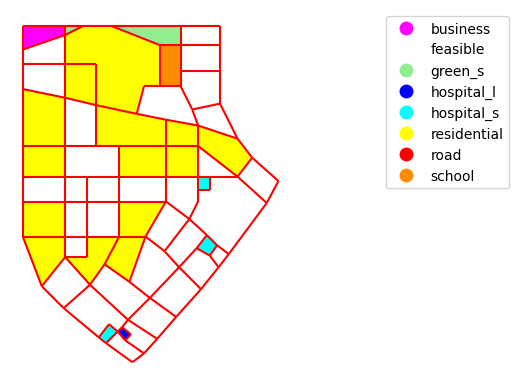

In [39]:
TYPE_COLOR_MAP = {
    'boundary': 'lightgreen',
    'business': 'fuchsia',
    'feasible': 'white',
    'green_l': 'green',
    'green_s': 'lightgreen',
    'hospital_l': 'blue',
    'hospital_s': 'cyan',
    'office': 'gold',
    'outside': 'black',
    'residential': 'yellow',
    'road': 'red',
    'school': 'darkorange',
    'recreation': 'lavender'
}

gdf_viz = copy.deepcopy(gdf_simplified[(gdf_simplified['existence'] == True) &
                                          (gdf_simplified['type'] != OUTSIDE) &
                                          (gdf_simplified['type'] != BOUNDARY) &
                                          (gdf_simplified['type'] != INTERSECTION)])
gdf_viz['legend'] = gdf_viz['type'].apply(lambda x: LAND_USE_ID_MAP_INV[x])
#gdf_viz = gdf_viz[gdf_viz.geom_type=='Polygon']
existing_types = sorted([LAND_USE_ID_MAP_INV[var] for var in gdf_viz['type'].unique()])
cmap = ListedColormap(
    [TYPE_COLOR_MAP[var] for var in existing_types])
gdf_viz.plot(
    'legend',
    cmap=cmap,
    categorical=True,
    legend=True,
    legend_kwds={'bbox_to_anchor': (1.8, 1)}
)
plt.xticks([])
plt.yticks([])
plt.axis('off')
plt.show()

In [40]:
d = dict()
d['gdf'] = gdf_simplified
with open('./init_plan_huizhou.pickle', 'wb') as f:
    pickle.dump(d, f)

In [6]:
d=pickle.load(open('./init_plan_huizhou.pickle', 'rb'))
gdf=d['gdf']
gdf.to_file('init_plan_huizhou.geopandas', driver='GeoJSON')